# **Nhanes Merges + Diabetes Level**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base = '/kaggle/input/datasets/nguyenvy/nhanes-19882018/'

demo = pd.read_csv(base + 'demographics_clean.csv', low_memory=False)
resp = pd.read_csv(base + 'response_clean.csv', low_memory=False)

print("Demo shape:", demo.shape)
print("Resp shape:", resp.shape)

Demo shape: (135310, 281)
Resp shape: (131030, 1038)


***Filter to 2015–2018***

In [2]:
# SDDSRVYR = 9 (2015-2016), 10 (2017-2018)
demo_filtered = demo[demo['SDDSRVYR'].isin([9, 10])].copy()
print("Rows after year filter:", len(demo_filtered))
print("Cycles:", demo_filtered['SDDSRVYR'].value_counts().sort_index())

Rows after year filter: 19225
Cycles: SDDSRVYR
9     9971
10    9254
Name: count, dtype: int64


In [3]:
# From DEMO
demo_cols = demo_filtered[['SEQN', 'RIDAGEYR', 'RIAGENDR', 'SDDSRVYR']].copy()
demo_cols.columns = ['SEQN', 'age', 'sex', 'cycle']

# From RESP — selecting only the columns we need
resp_cols = resp[['SEQN',
                  'BMXBMI', 'BMXWAIST',
                  'BPXSY1', 'BPXSY2', 'BPXDI1', 'BPXDI2',
                  'LBXGH', 'LBXGLU']].copy()

# Average BP readings
resp_cols['sbp'] = resp_cols[['BPXSY1', 'BPXSY2']].mean(axis=1)
resp_cols['dbp'] = resp_cols[['BPXDI1', 'BPXDI2']].mean(axis=1)

resp_cols = resp_cols[['SEQN', 'BMXBMI', 'BMXWAIST', 'sbp', 'dbp', 'LBXGH', 'LBXGLU']].copy()
resp_cols.columns = ['SEQN', 'bmi', 'waist', 'sbp', 'dbp', 'a1c', 'glucose']

print("Columns ready")
print(resp_cols.head())

Columns ready
   SEQN    bmi   waist    sbp   dbp   a1c     glucose
0     9  27.50   92.30  129.5  74.5  5.35  130.525000
1    48  36.25  108.50  134.0  78.0  4.85   84.900000
2    92  26.15   84.40   97.5  21.0  4.65         NaN
3    94  21.90   77.25  103.0  51.5  5.90         NaN
4   106  25.55  101.05  147.5  80.5  5.25   98.933333


# **Merge**

In [4]:
df = demo_cols.merge(resp_cols, on='SEQN', how='left')

print("Merged shape:", df.shape)
print(df.head())

Merged shape: (19225, 10)
    SEQN  age  sex  cycle   bmi  waist    sbp   dbp  a1c  glucose
0  83732   62    1      9  27.8  101.1  126.0  67.0  7.0      NaN
1  83733   53    1      9  30.8  107.9  143.0  88.0  5.5    101.0
2  83734   78    1      9  28.8  116.5  135.0  45.0  5.8     84.0
3  83735   56    2      9  42.4  110.1  133.0  70.0  5.6      NaN
4  83736   42    2      9  20.3   80.4  107.0  62.0  5.6     84.0


***check diabetic label***

In [5]:
def make_label(row):
    a1c = row['a1c']
    glc = row['glucose']
    if pd.isna(a1c) and pd.isna(glc):
        return np.nan
    if (not pd.isna(a1c) and a1c >= 6.5) or (not pd.isna(glc) and glc >= 126):
        return 1
    return 0

df['diabetes'] = df.apply(make_label, axis=1)

print("Label distribution (including NaN):")
print(df['diabetes'].value_counts(dropna=False))
print(f"\nDiabetes prevalence (labelled rows): {df['diabetes'].mean()*100:.1f}%")

Label distribution (including NaN):
diabetes
0.0    10688
NaN     6848
1.0     1689
Name: count, dtype: int64

Diabetes prevalence (labelled rows): 13.6%


In [6]:
# Duplicates
dups = df['SEQN'].duplicated().sum()
print(f"Duplicate SEQNs: {dups}")

# Missing values table
missing = pd.DataFrame({
    'column': df.columns,
    'missing_n': df.isnull().sum().values,
    'missing_pct': (df.isnull().sum().values / len(df) * 100).round(1)
})
print("\n=== MISSING VALUES TABLE ===")
print(missing.to_string(index=False))

Duplicate SEQNs: 0

=== MISSING VALUES TABLE ===
  column  missing_n  missing_pct
    SEQN          0          0.0
     age          0          0.0
     sex          0          0.0
   cycle          0          0.0
     bmi       2464         12.8
   waist       3311         17.2
     sbp       5190         27.0
     dbp       5190         27.0
     a1c       6854         35.7
 glucose      13362         69.5
diabetes       6848         35.6


In [7]:
# Full merged file
df.to_csv('merged_with_label.csv', index=False)

# Clean file: have a label + core screening features
df_clean = df.dropna(subset=['diabetes']).copy()
df_clean = df_clean.dropna(subset=['age', 'sex', 'bmi', 'sbp', 'dbp'])

# Adults only diabetes screening is for adults
df_clean = df_clean[df_clean['age'] >= 18]

print("Clean dataset shape:", df_clean.shape)
print("\nDiabetes distribution in clean set:")
print(df_clean['diabetes'].value_counts())
print(f"\nPrevalence: {df_clean['diabetes'].mean()*100:.1f}%")

df_clean.to_csv('nhanes_diabetes_clean.csv', index=False)
print("\nBoth files saved ✓")

Clean dataset shape: (10168, 11)

Diabetes distribution in clean set:
diabetes
0.0    8591
1.0    1577
Name: count, dtype: int64

Prevalence: 15.5%

Both files saved ✓


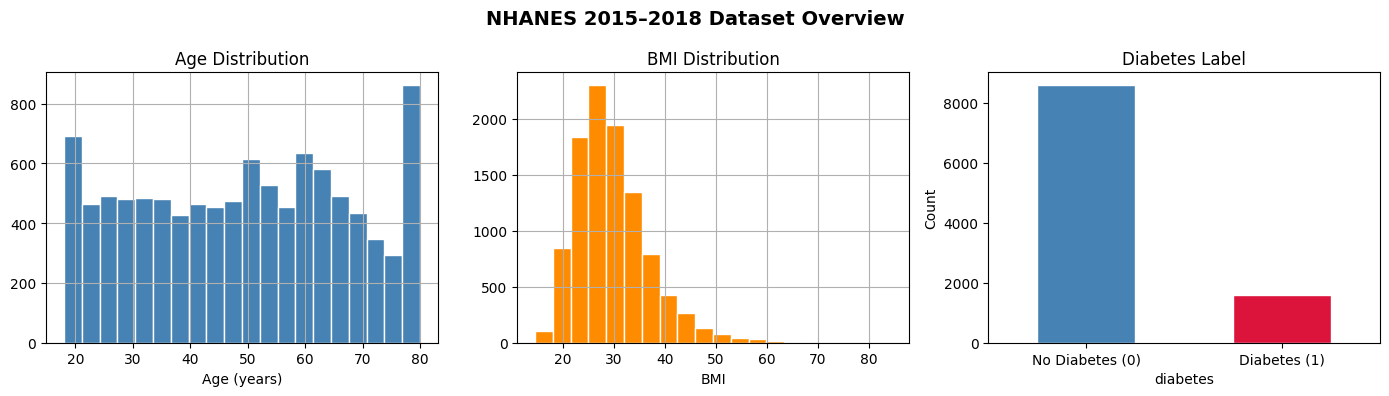

Plot saved ✓


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('NHANES 2015–2018 Dataset Overview', fontsize=14, fontweight='bold')

df_clean['age'].hist(ax=axes[0], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age (years)')

df_clean['bmi'].hist(ax=axes[1], bins=20, color='darkorange', edgecolor='white')
axes[1].set_title('BMI Distribution')
axes[1].set_xlabel('BMI')

df_clean['diabetes'].value_counts().plot(
    kind='bar', ax=axes[2], 
    color=['steelblue', 'crimson'],
    edgecolor='white'
)
axes[2].set_title('Diabetes Label')
axes[2].set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'], rotation=0)
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('data_overview.png', dpi=150)
plt.show()
print("Plot saved ✓")